In [167]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
import copy
import math
%matplotlib inline

In [168]:
x_train, y_train = load_data()


In [169]:
#print what x train contains

print("Type of x_train:",type(x_train))
print("First five elements of x_train are:\n", x_train[:5]) 

print("Type of y_train:",type(y_train))
print("First five elements of y_train are:\n", y_train[:5]) 

Type of x_train: <class 'numpy.ndarray'>
First five elements of x_train are:
 [6.1101 5.5277 8.5186 7.0032 5.8598]
Type of y_train: <class 'numpy.ndarray'>
First five elements of y_train are:
 [17.592   9.1302 13.662  11.854   6.8233]


shape of x_train: 97
shape of y_train: 97
Number of training examples (m): 97


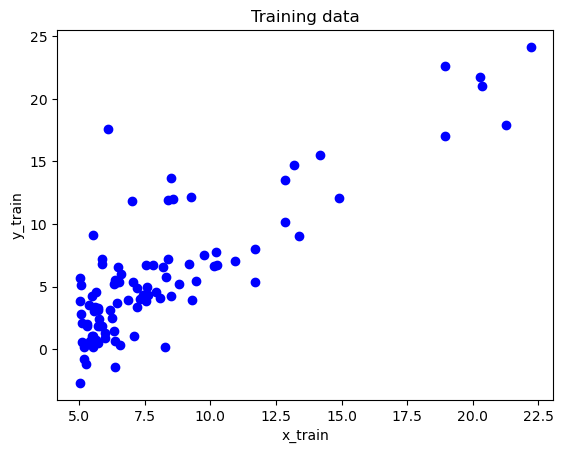

In [170]:
print("shape of x_train:",x_train.shape[0])
print("shape of y_train:",y_train.shape[0])

print ('Number of training examples (m):', len(x_train))

plot = plt.scatter(x_train, y_train, color='blue')
title = plt.title('Training data')
axis1 = plt.xlabel('x_train')
axis2 = plt.ylabel('y_train')


# METHOD 2: The Explicit Object-Oriented Way (Recommended for scaling)
# Gives you direct variable handles to the canvas container and the grid
#fig, ax = plt.subplots() # fig = entire window frame, ax = the actual grid plot
#ax.scatter(x_train, y_train, marker='x', c='b')
#ax.set_xlabel("Population of City in 10,000s") # Notice the '.set_' prefix here!
#ax.set_ylabel("Profit in $10,000s")
#ax.set_title("Profits vs. Population")
#plt.show()
#CAN DO fig.save OR fig.set_size to change canvas size etc

In [171]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost = 0.0
    for i in range(m):
        prediction = w * x[i] + b
        cost += ((prediction - y[i]) ** 2)/(2*m)
    return cost

In [172]:
#TEST if code is cocrect 
# Compute cost with some initial values for paramaters w, b
initial_w = 2
initial_b = 1

cost = compute_cost(x_train, y_train, initial_w, initial_b)
print(type(cost))
print(f'Cost at initial w (zeros): {cost:.3f}')

# Public tests
from public_tests import *
compute_cost_test(compute_cost)

<class 'numpy.float64'>
Cost at initial w (zeros): 75.203
All tests passed!


In [173]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0.0
    dj_db = 0.0
    for i in range(m):
        prediction = w * x[i] + b
        dj_dw += (prediction - y[i]) * x[i]
        dj_db += prediction - y[i]
    dj_dw /= m
    dj_db /= m
    return dj_dw, dj_db
        

In [174]:
#TEST CHECK
# Compute and display gradient with w initialized to zeroes
initial_w = 0
initial_b = 0

tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, initial_w, initial_b)
print('Gradient at initial w, b (zeros):', tmp_dj_dw, tmp_dj_db)

compute_gradient_test(compute_gradient)

Gradient at initial w, b (zeros): -65.32884974555672 -5.83913505154639
Using X with shape (4, 1)
All tests passed!


In [175]:
def gradient_descent(x, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
  

  # An array to store cost J and w's at each iteration — primarily for graphing later
    J_history = []
    w_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x, y, w, b) 

        # FIX 2: Update 'w' and 'b', which are the variables tracking your progress
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
         # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            cost =  cost_function(x, y, w, b)
            J_history.append(cost)

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0:
            w_history.append(w)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")

        
    return w, b, J_history, w_history #return w and J,w history for graphing






In [176]:
initial_w = 0.
initial_b = 0.

# some gradient descent settings
iterations = 1500
alpha = 0.01

w,b,_,_ = gradient_descent(x_train ,y_train, initial_w, initial_b, 
                     compute_cost, compute_gradient, alpha, iterations)
print("w,b found by gradient descent:", w, b)

Iteration    0: Cost     6.74   
Iteration  150: Cost     5.31   
Iteration  300: Cost     4.96   
Iteration  450: Cost     4.76   
Iteration  600: Cost     4.64   
Iteration  750: Cost     4.57   
Iteration  900: Cost     4.53   
Iteration 1050: Cost     4.51   
Iteration 1200: Cost     4.50   
Iteration 1350: Cost     4.49   
w,b found by gradient descent: 1.166362350335582 -3.63029143940436


Text(0.5, 0, 'Population of City in 10,000s')

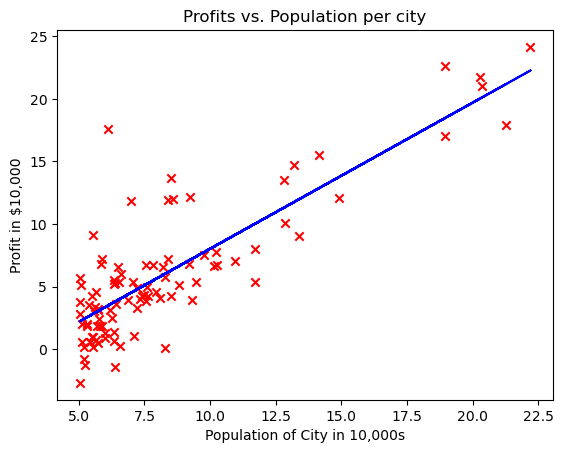

In [ ]:
#we take final weight final value of x_train and b and get the line

m = x_train.shape[0]
predicted = np.zeros(m)

for i in range(m):
    predicted[i] = w * x_train[i] + b

# Plot the linear fit
plt.plot(x_train, predicted, c = "b")

# Create a scatter plot of the data. 
plt.scatter(x_train, y_train, marker='x', c='r') 

# Set the title
plt.title("Profits vs. Population per city")
# Set the y-axis label
plt.ylabel('Profit in $10,000')
# Set the x-axis label
plt.xlabel('Population of City in 10,000s')